# La Red Neuronal como Maquina Geometrica
**Objetivo del bloque**: entender que una red neuronal no es misteriosa.
Es una función matemática que transforma el espacio de datos para hacer
linealmente separable lo que originalmente no lo era.

Este bloque construye esa maquina desde cero:
la neurona individual, como se organizan en capas,
y como las funciones de activación introducen la no linealidad que lo hace posible.

---

**Estructura del notebook:**
1. La neurona como unidad de computo - producto escalar + sesgo
2. Capas densas - por que los batches y la ruptura de simetria
3. Funciones de activación - ReLU y Softmax desde la geometría
4. Pipeline completo: Dense -> ReLU -> Dense -> Softmax
5. Visualización: que hace una red con el espacio de datos
6. Analogia .NET - para desarrolladores del el equipo

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
# Setup
from pathlib import Path
import os

SCRIPTS = Path('..') / 'ejemplos_codigo'
if not SCRIPTS.is_dir():
    raise FileNotFoundError(
        f"No se encuentra '{SCRIPTS.resolve()}'.\n"
        "Ejecuta este notebook desde la carpeta Jupyter_notebooks/"
    )

os.chdir(SCRIPTS)
print(f"[OK] Directorio de scripts: {os.getcwd()}")

%pip install -q scikit-learn matplotlib numpy
%matplotlib inline

[OK] Directorio de scripts: D:\documentos_gdrive\proyectos_claude_mcp\projects\formación_AI_springter\ejemplos_codigo
Note: you may need to restart the kernel to use updated packages.


---
## 1. La Neurona como Unidad de Computo

Una neurona artificial es simple: recibe entradas, las pondera con pesos, suma un sesgo.

```
output = x1*w1 + x2*w2 + x3*w3 + bias
       = dot(inputs, weights) + bias
```

- **Pesos (weights)**: la importancia relativa de cada entrada. Son lo que el entrenamiento ajusta.
- **Sesgo (bias)**: permite desplazar la función. Sin sesgo, si todas las entradas son 0, la salida siempre es 0.

**Por que NumPy en lugar de bucles:**
NumPy delega las operaciones matriciales a librerías compiladas en C (BLAS/LAPACK)
que aprovechan instrucciones SIMD del procesador.

Para un desarrollador .NET: es la diferencia entre un `foreach` y operaciones
vectorizadas con `System.Numerics.Vector`.

> **Antes de seguir:** ¿puedes describir una tarea de tu trabajo donde el resultado correcto sería difícil de explicar como regla escrita, pero que reconocerías de inmediato si lo vieras?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Una tarea donde el juicio humano es fluido pero la verbalización de las reglas es incompleta (clasificar si un email es urgente, decidir si un diseño es adecuado, detectar si un pedido parece fraudulento)
- La diferencia entre saber hacer algo y saber explicar cómo se hace
- Cómo esa brecha entre conocimiento implícito y explícito es exactamente lo que las neuronas artificiales intentan capturar

**Si nadie responde, preguntar:**
"¿Cuántas reglas necesitaríais para clasificar automáticamente si un ticket de soporte es urgente de verdad? ¿Cuántas excepciones tendría cada regla?"

**Señal de comprensión:**
El alumno identifica que el aprendizaje automático es útil precisamente cuando el conocimiento es implícito: sabemos reconocer el resultado correcto (podemos etiquetar ejemplos) pero no sabemos escribir el algoritmo que lo produce.

</details>

In [3]:
# Neurona simple: producto escalar + sesgo
# Muestra Python puro vs NumPy y el rendimiento de la vectorizacion
%run 01_neurona_simple.py

=== Neurona simple (Python puro) ===
Inputs:  [1.0, 2.0, 3.0]
Weights: [0.2, 0.8, -0.5]
Bias:    2.0
Output:  2.3

=== Neurona con bucle (4 inputs) ===
Output: 4.8

=== Neurona con NumPy (np.dot) ===
Output: 4.8

=== Capa de 3 neuronas ===
Output de la capa: [4.8   1.21  2.385]

=== Batch de 3 muestras, capa de 3 neuronas ===
Shape del output: (3, 3)
Output:
[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]


In [4]:
import numpy as np

# Neurona manual: interpreta los numeros
# Simulemos una neurona que evalua el riesgo de churn de un cliente
# Features: [meses_sin_login, tickets_abiertos, modulos_activos, ratio_pago_puntual]

features_cliente = np.array([3.0, 5.0, 2.0, 0.7])
# Pesos aprendidos por el modelo (en produccion estos los aprende el entrenamiento)
pesos = np.array([0.4, 0.3, -0.2, -0.5])  # login sin usar + tickets = riesgo; modulos y pago = proteccion
sesgo = -0.1

output_raw = np.dot(features_cliente, pesos) + sesgo
print(f"Features: {features_cliente}")
print(f"Pesos:    {pesos}")
print(f"Sesgo:    {sesgo}")
print(f"Output bruto (antes de activacion): {output_raw:.4f}")
print()

# Aplicar sigmoide para convertir en probabilidad
prob_churn = 1 / (1 + np.exp(-output_raw))
print(f"Probabilidad de churn: {prob_churn:.4f} ({prob_churn*100:.1f}%)")
print()

# Contribucion de cada feature
print("Contribucion de cada feature:")
nombres = ["meses_sin_login", "tickets_abiertos", "modulos_activos", "ratio_pago"]
for n, f, w in zip(nombres, features_cliente, pesos):
    contrib = f * w
    signo = "+" if contrib > 0 else ""
    print(f"  {n:22s}: {f:.1f} * {w:+.1f} = {signo}{contrib:.2f}")

Features: [3.  5.  2.  0.7]
Pesos:    [ 0.4  0.3 -0.2 -0.5]
Sesgo:    -0.1
Output bruto (antes de activacion): 1.8500

Probabilidad de churn: 0.8641 (86.4%)

Contribucion de cada feature:
  meses_sin_login       : 3.0 * +0.4 = +1.20
  tickets_abiertos      : 5.0 * +0.3 = +1.50
  modulos_activos       : 2.0 * -0.2 = -0.40
  ratio_pago            : 0.7 * -0.5 = -0.35


---
## 2. Capas Densas y Operaciones Matriciales

Una capa densa es un conjunto de neuronas que reciben todas las salidas de la capa anterior.
Si una capa tiene N neuronas y recibe M entradas:

```
output = X @ W + b
```

- X: (batch_size, M) - varias muestras procesadas en paralelo
- W: (M, N) - matrix de pesos
- b: (1, N) - vector de sesgos
- Resultado: (batch_size, N)

**Por que batches:**
1. Las GPUs estan optimizadas para multiplicaciones de matrices grandes
2. El gradiente sobre un batch es mas estable que el de una sola muestra
3. Permite paralelismo: todas las muestras se procesan simultaneamente

**Ruptura de simetría** (por que los pesos se inicializan aleatoriamente, no a cero):
Si todos los pesos son identicos, todas las neuronas calculan lo mismo
y sus gradientes son identicos. Nunca aprenden representaciones diferentes.
Los valores aleatorios pequeños (0.01 * randn) rompen esa simetría.

In [5]:
# Capas densas y batches
# Muestra la clase Layer_Dense y como procesa un batch de muestras
%run 02_capa_densa.py

Shape de X: (300, 2)
Shape de y: (300,)
Clases: [0 1 2]

Shape del output de la capa: (300, 3)
Primeras 5 salidas:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.04751877e-04  1.13953608e-04 -4.79835027e-05]
 [-2.74148425e-04  3.17291492e-04 -8.69217965e-05]
 [-4.21883664e-04  5.26662557e-04 -5.59126778e-05]
 [-5.77076817e-04  7.14014087e-04 -8.94304470e-05]]

Shape del output de la segunda capa: (300, 3)
Primeras 5 salidas de la segunda capa:
[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.75651160e-06 1.60895890e-06 6.86066362e-07]
 [4.13099288e-06 3.90289939e-06 1.85216568e-06]
 [5.41864346e-06 5.38596661e-06 2.96435410e-06]
 [7.56804485e-06 7.47039493e-06 4.03583830e-06]]


In [6]:
import numpy as np

# Demostracion de ruptura de simetria
# Con pesos a cero: todas las neuronas aprenden lo mismo
# Con pesos aleatorios: cada neurona evoluciona independientemente

np.random.seed(42)
n_inputs, n_neuronas = 4, 3
X_batch = np.random.randn(5, n_inputs)  # 5 muestras, 4 features

# Caso 1: pesos a cero
W_cero = np.zeros((n_inputs, n_neuronas))
output_cero = X_batch @ W_cero

# Caso 2: pesos aleatorios
W_random = 0.01 * np.random.randn(n_inputs, n_neuronas)
output_random = X_batch @ W_random

print("Con pesos a CERO (simetria sin romper):")
print(output_cero[:3])
print("-> Las 3 neuronas producen exactamente lo mismo. No pueden diferenciarse.")
print()
print("Con pesos ALEATORIOS (simetria rota):")
print(output_random[:3].round(6))
print("-> Cada neurona produce valores distintos. Pueden especializarse.")

Con pesos a CERO (simetria sin romper):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
-> Las 3 neuronas producen exactamente lo mismo. No pueden diferenciarse.

Con pesos ALEATORIOS (simetria rota):
[[-0.002647 -0.0071    0.024503]
 [-0.020511  0.003119  0.004312]
 [-0.007919 -0.000832 -0.005558]]
-> Cada neurona produce valores distintos. Pueden especializarse.


---
## 3. Funciones de Activación: por que son imprescindibles

Sin funciones de activación no lineales, una red profunda se comportaria
como una única transformación lineal.

```
capa2(capa1(x)) = W2 @ (W1 @ x + b1) + b2
               = (W2@W1) @ x + (W2@b1 + b2)
               = W_efectiva @ x + b_efectiva
```

Dos capas lineales son equivalentes a una sola. No importa cuantas capas apiles.
La no linealidad es lo que permite aprender representaciones complejas.

### ReLU (Rectified Linear Unit) - para capas ocultas
```
ReLU(x) = max(0, x)
```
Simple, rápida, evita el desvanecimiento del gradiente para valores positivos.

### Softmax - para la capa de salida en clasificación
```
softmax(z_i) = exp(z_i) / sum(exp(z_j))
```
Convierte un vector de números en una distribución de probabilidad (suma = 1).

In [7]:
# ReLU y Softmax: implementacion y efecto
# Incluye el pipeline Dense -> ReLU -> Dense -> Softmax
%run 03_activaciones_relu_softmax.py

=== Demostracion de ReLU ===
Input:
[[-1.   2.  -0.5  3.3]
 [ 0.  -2.7  1.1  2.2]]
Output ReLU:
[[0.  2.  0.  3.3]
 [0.  0.  1.1 2.2]]

=== Demostracion de Softmax ===
Input:
[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]
Output Softmax (probabilidades):
[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]
Suma por muestra: [1. 1. 1.]

=== Pipeline: Dense -> ReLU -> Dense -> Softmax ===
Predicciones (primeras 5 muestras):
[[0.33333333 0.33333333 0.33333333]
 [0.33333317 0.33333318 0.33333364]
 [0.33333289 0.33333292 0.3333342 ]
 [0.33333259 0.33333264 0.33333477]
 [0.33333233 0.33333239 0.33333528]]
Clases predichas: [0 2 2 2 2]
Clases reales:    [0 0 0 0 0]


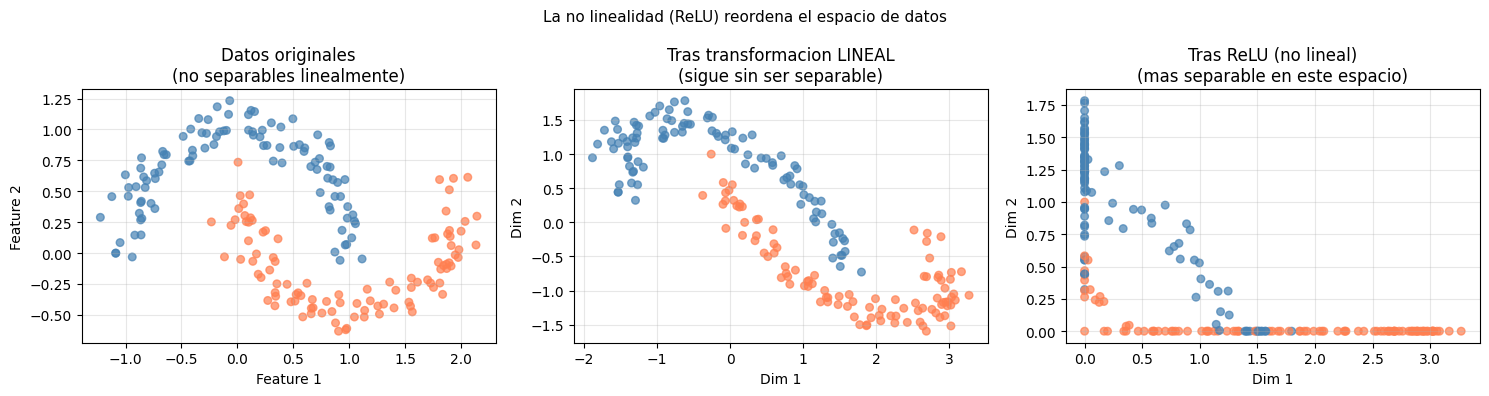

Una red con multiples capas y ReLU aprende a doblar y transformar
el espacio de datos hasta que las clases sean separables.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizacion geometrica: que hace ReLU al espacio de datos
# Datos no separables linealmente (dos lunas)
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Transformacion lineal primero
W1 = np.array([[1.5, -0.5], [-0.5, 1.5]])
b1 = np.array([0.1, -0.1])
X_lineal = X @ W1 + b1

# Aplicar ReLU
X_relu = np.maximum(0, X_lineal)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = ['steelblue' if c == 0 else 'coral' for c in y]

axes[0].scatter(X[:, 0], X[:, 1], c=colores, alpha=0.7, s=30)
axes[0].set_title('Datos originales\n(no separables linealmente)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_lineal[:, 0], X_lineal[:, 1], c=colores, alpha=0.7, s=30)
axes[1].set_title('Tras transformacion LINEAL\n(sigue sin ser separable)')
axes[1].set_xlabel('Dim 1')
axes[1].set_ylabel('Dim 2')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_relu[:, 0], X_relu[:, 1], c=colores, alpha=0.7, s=30)
axes[2].set_title('Tras ReLU (no lineal)\n(mas separable en este espacio)')
axes[2].set_xlabel('Dim 1')
axes[2].set_ylabel('Dim 2')
axes[2].grid(True, alpha=0.3)

plt.suptitle('La no linealidad (ReLU) reordena el espacio de datos', fontsize=11)
plt.tight_layout()
plt.savefig('images/B03_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print("Una red con multiples capas y ReLU aprende a doblar y transformar")
print("el espacio de datos hasta que las clases sean separables.")

---
## 4. Pipeline Completo y Analogia .NET

El pipeline de inferencia de una red neuronal:

```
Input → [Dense] → [ReLU] → [Dense] → [ReLU] → [Dense] → [Softmax] → Probabilidades
```

**Analogia para desarrolladores .NET:**
- `fit()` = compilar el modelo con los datos (el constructor que aprende los parámetros)
- `predict()` = usar el modelo compilado (la llamada al servicio en producción)
- Los pesos aprendidos son los parámetros internos de un servicio que se serializa y despliega
- El batch es equivalente a una operación LINQ sobre una colección
- Self-attention en Transformers es como un LINQ JOIN donde la condición es la similaridad semántica

El modelo entrenado es un archivo `.pkl` o `.onnx` que se carga como un
servicio en la API de la empresa. No es diferente a cargar un servicio compilado.

In [9]:
import numpy as np

# Pipeline manual desde cero: sin librerias de ML
# Para entender exactamente que hace una red en inferencia

np.random.seed(42)

class NeuronLayer:
    def __init__(self, n_inputs, n_neurons):
        self.W = 0.1 * np.random.randn(n_inputs, n_neurons)
        self.b = np.zeros(n_neurons)

    def forward(self, X):
        return X @ self.W + self.b

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

# Red para clasificar tickets de soporte en 3 categorias:
# [bug, feature_request, pregunta_configuracion]
# Features: [longitud_texto, contiene_error, contiene_como, n_adjuntos, hora_dia]

layer1 = NeuronLayer(n_inputs=5, n_neurons=8)    # capa oculta 1
layer2 = NeuronLayer(n_inputs=8, n_neurons=6)    # capa oculta 2
layer3 = NeuronLayer(n_inputs=6, n_neurons=3)    # capa de salida (3 clases)

# Ejemplo: 4 tickets con sus features
tickets = np.array([
    [450, 1, 0, 2, 9.0],    # Texto largo, contiene "error", 2 adjuntos -> probablemente bug
    [180, 0, 0, 0, 14.5],   # Texto corto, sin error, sin adjuntos -> feature request?
    [320, 0, 1, 1, 10.0],   # Contiene "como", 1 adjunto -> pregunta de configuracion
    [600, 1, 1, 3, 17.0],   # Largo, con error y como, muchos adjuntos -> ambiguo
])

# Normalizar features (en produccion esto se hace con un scaler entrenado)
tickets_norm = (tickets - tickets.mean(axis=0)) / (tickets.std(axis=0) + 1e-8)

# Forward pass
h1 = relu(layer1.forward(tickets_norm))
h2 = relu(layer2.forward(h1))
logits = layer3.forward(h2)
probs = softmax(logits)

print("Probabilidades por ticket (pesos aleatorios, sin entrenar):")
print(f"{'Ticket':>8} | {'P(bug)':>8} | {'P(feature)':>10} | {'P(config)':>10} | {'Clase':>10}")
print("-" * 55)
clases = ["bug", "feature", "config"]
for i, (p, t) in enumerate(zip(probs, tickets)):
    clase = clases[np.argmax(p)]
    print(f"Ticket {i+1:>3} | {p[0]:>8.3f} | {p[1]:>10.3f} | {p[2]:>10.3f} | {clase:>10}")

print()
print("[!] Los pesos son aleatorios: las predicciones son ruido.")
print("    El entrenamiento (Bloque 4) ajusta los pesos hasta que las predicciones son correctas.")

Probabilidades por ticket (pesos aleatorios, sin entrenar):
  Ticket |   P(bug) | P(feature) |  P(config) |      Clase
-------------------------------------------------------
Ticket   1 |    0.334 |      0.333 |      0.333 |        bug
Ticket   2 |    0.335 |      0.332 |      0.333 |        bug
Ticket   3 |    0.335 |      0.332 |      0.333 |        bug
Ticket   4 |    0.332 |      0.334 |      0.334 |    feature

[!] Los pesos son aleatorios: las predicciones son ruido.
    El entrenamiento (Bloque 4) ajusta los pesos hasta que las predicciones son correctas.


---
## 7. Ejercicio de Decisión: ¿usarias IA aquí?

### Caso: red neuronal para detectar anomalias en logs del ERP

El sistema de monitorizacion del ERP de la empresa detecta anomalias en los logs
usando umbrales fijos (si el tiempo de respuesta supera X ms, es anomalia).
El sistema actual tiene un 5% de falsos positivos.

Un proveedor de MLOps propone reemplazarlo por una red neuronal profunda de 12 capas
entrenada sobre el historial de logs. Argumenta que "aprendera los patrones reales
y reducira los falsos positivos".

---

**Pregunta 1 - Antes de decidir**
¿Que información necesitarias antes de evaluar si una red de 12 capas tiene sentido?
Lista al menos 4 preguntas que le harias al proveedor.

**Pregunta 2 - El 5% de falsos positivos**
¿Es el 5% un indicador de que el sistema actual es malo?
¿Que dato adicional necesitas para saberlo?

**Pregunta 3 - El problema del etiquetado**
Una red neuronal supervisada necesita logs etiquetados (anomalia real / no anomalia).
¿Como obtendrías esas etiquetas? ¿Que dificultades anticipas?

**Pregunta 4 - La decisión**
¿Usarias la red de 12 capas, una arquitectura mas simple, o mantendrias los umbrales?
¿Por que?

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - Antes de decidir:**

*(escribe aquí)*

**Pregunta 2 - El 5% de falsos positivos:**

*(escribe aquí)*

**Pregunta 3 - El problema del etiquetado:**

*(escribe aquí)*

**Pregunta 4 - La decisión:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - Antes de decidir:
Preguntas validas al proveedor:
 - Cuantos logs etiquetados (anomalia real vs normal) hay disponibles?
 - Cual es la latencia máxima aceptable para detección?
 - Con que frecuencia cambian los patrones del sistema (drift)?
 - Que significa exactamente "anomalia" para el equipo de operaciones?
 - El modelo ha sido evaluado en producción o solo en datos históricos?
Insuficiente: preguntar solo sobre el precio o la infraestructura.
Incorrecto: aceptar la propuesta sin preguntar nada.

Pregunta 2 - El 5% de falsos positivos:
No es suficiente saber que el 5% es falsos positivos.
Datos adicionales necesarios: cuantas alertas se generan al dia (5% de 10 alertas vs 5% de 10.000),
y cual es el coste de un falso negativo (anomalia real no detectada).
Un alumno que solo menciona el volumen de alertas tiene una respuesta parcial.
Respuesta completa: menciona tanto volumen como asimetria entre tipos de error.

Pregunta 3 - El etiquetado:
Dificultades a anticipar: las anomalias reales son raras (pocos ejemplos positivos),
el concepto de anomalia puede ser ambiguo para el equipo, y las etiquetas históricas
pueden estar sesgadas (solo se etiqueto lo que el sistema previo ya detecto).
Propuesta valida: revisión manual de un sample + criterios claros con el equipo de ops.
Incompleto: "usaria datos históricos del sistema actual" sin mencionar el sesgo de selección.

Pregunta 4 - La decisión:
Respuesta solida: proponer primero un modelo mas simple (isolation forest, umbral adaptativo)
antes de una red de 12 capas. Justificar la complejidad solo si los resultados del modelo
simple no son suficientes.
Penalizar: "usaria la red de 12 capas porque es mas potente" sin evaluar el sobreajuste
o la dificultad de explicabilidad para el equipo de operaciones.
-->


---
## Puntos clave del Bloque 3

1. **La neurona es simple**: producto escalar + sesgo. La magia viene de apilar muchas.

2. **Sin no linealidad, no hay profundidad real**: las capas lineales se colapsan
   matemáticamente en una sola transformación. ReLU es lo que las hace independientes.

3. **La red transforma el espacio**: en cada capa, los datos se proyectan a un nuevo
   espacio donde las clases son progresivamente mas separables.

4. **Inferencia = multiplicación de matrices**: en producción, una red neuronal
   es una secuencia de multiplicaciones de matrices y aplicaciones de funciones.
   Rápido, paralelizable, desplegable como cualquier API.

5. **Los pesos aleatorios son ruido**: la red en este estado produce predicciones
   sin sentido. El entrenamiento es el proceso de ajustar esos pesos.

---
**Siguiente bloque**: El Aprendizaje como Optimización - 
como medir el error, propagarlo hacia atras y ajustar los pesos.